In [2]:
# Import Libraries
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Download gold futures data from Yahoo Finance
gold_data = yf.download('GC=F', start='2010-01-01', end='2023-01-01', auto_adjust=True)


# Display the first few rows of the dataset
print(gold_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2010-01-04  1117.699951  1122.300049  1097.099976  1117.699951    184
2010-01-05  1118.099976  1126.500000  1115.000000  1118.099976     53
2010-01-06  1135.900024  1139.199951  1120.699951  1135.900024    363
2010-01-07  1133.099976  1133.099976  1129.199951  1133.099976     56
2010-01-08  1138.199951  1138.199951  1122.699951  1138.199951     54


In [3]:
# Use 'Close' price as the target variable
gold_data = gold_data[['Close']]
gold_data = gold_data.dropna()  # Drop any rows with NaN values

# Reset index to use the date as a feature
gold_data.reset_index(inplace=True)

# Convert 'Date' to numerical format
gold_data['Date'] = gold_data['Date'].map(pd.Timestamp.toordinal)

# Display the first few rows after preprocessing
print(gold_data.head())


Price     Date        Close
Ticker                 GC=F
0       733776  1117.699951
1       733777  1118.099976
2       733778  1135.900024
3       733779  1133.099976
4       733780  1138.199951


In [5]:
# Define features (X) and target (y)
X = gold_data[['Date']]
y = gold_data['Close']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

In [7]:
y_pred = model.predict(X_test)

In [8]:
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 51075.211915630076
R² Score: 0.15022079688041157


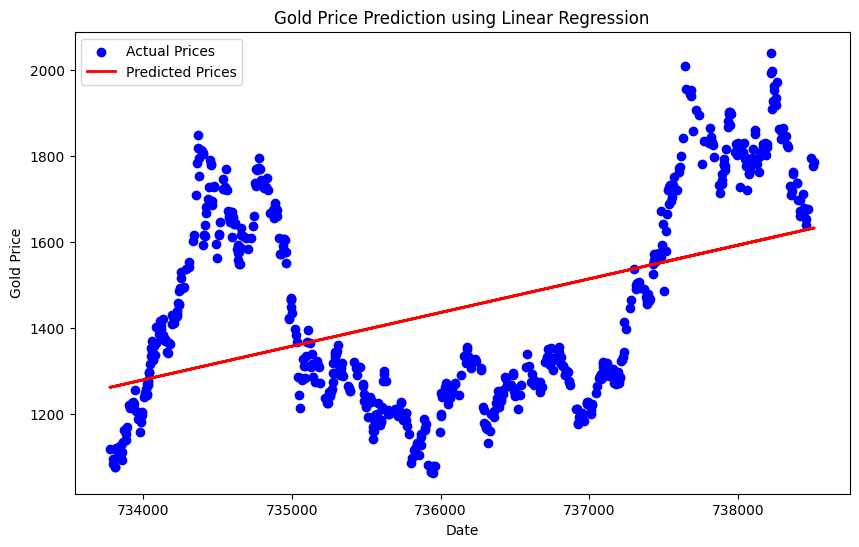

In [9]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.title('Gold Price Prediction using Linear Regression')
plt.legend()
plt.show()

In [6]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()